In [19]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

In [20]:
# 2A top-1 % redocking success GNINA
autobox = 73
blind = 38

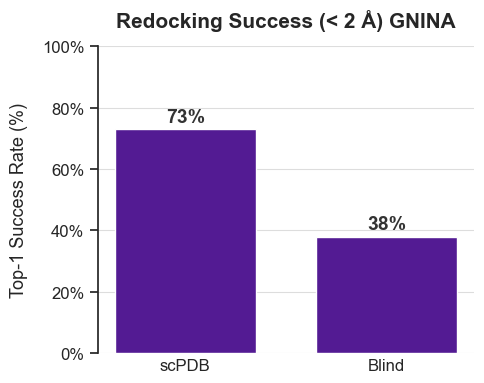

In [21]:

# ── config ────────────────────────────────────────────────────────────────────
COLOR = "#531B93"   # change this to any hex / named color
# ─────────────────────────────────────────────────────────────────────────────

labels = ["scPDB", "Blind"]
values = [73, 38]

sns.set_theme(style="ticks", font="sans-serif")
fig, ax = plt.subplots(figsize=(5, 4))

bars = ax.bar(labels, values, color=COLOR, width=0.7, zorder=2)

# value labels on top of bars
for bar in bars:
    h = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2, h + 1.2,
        f"{h}%", ha="center", va="bottom", fontsize=14, fontweight="bold", color="#333333"
    )

ax.set_ylabel("Top-1 Success Rate (%)", fontsize=13, labelpad=10)
ax.set_title("Redocking Success (< 2 Å) GNINA", fontsize=15, fontweight="bold", pad=14)
ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%d%%"))
ax.tick_params(axis="both", labelsize=12)
ax.tick_params(axis="x", length=0)

sns.despine(left=False, bottom=True)
ax.grid(axis="y", color="#dddddd", linewidth=0.8, zorder=0)

plt.tight_layout()
plt.savefig("figs/redocking_success.svg", format="svg", bbox_inches="tight")
plt.show()


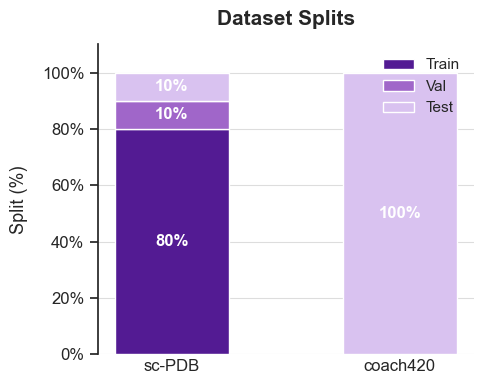

In [22]:

# ── config ────────────────────────────────────────────────────────────────────
COLORS = {"Train": "#531B93", "Val": "#A066C9", "Test": "#D9C2F0"}
# ─────────────────────────────────────────────────────────────────────────────

import numpy as np

datasets = ["sc-PDB", "coach420"]
train   = [80,   0]
val     = [10,   0]
test    = [10, 100]

sns.set_theme(style="ticks", font="sans-serif")
fig, ax = plt.subplots(figsize=(5, 4))

x = np.arange(len(datasets))
w = 0.5

b_train = ax.bar(x, train, width=w, label="Train", color=COLORS["Train"],  zorder=2)
b_val   = ax.bar(x, val,   width=w, label="Val",   color=COLORS["Val"],   bottom=train, zorder=2)
b_test  = ax.bar(x, test,  width=w, label="Test",  color=COLORS["Test"],  bottom=[t+v for t,v in zip(train, val)], zorder=2)

# segment labels (only when segment > 0)
for bars, bottoms, label_vals in [
    (b_train, [0]*2, train),
    (b_val,   train, val),
    (b_test,  [t+v for t,v in zip(train,val)], test),
]:
    for bar, bot, val_ in zip(bars, bottoms, label_vals):
        if val_ > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bot + val_ / 2,
                f"{val_}%", ha="center", va="center",
                fontsize=12, fontweight="bold", color="white"
            )

ax.set_xticks(x)
ax.set_xticklabels(datasets, fontsize=13)
ax.set_ylabel("Split (%)", fontsize=13, labelpad=10)
ax.set_title("Dataset Splits", fontsize=15, fontweight="bold", pad=14)
ax.set_ylim(0, 110)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%d%%"))
ax.tick_params(axis="both", labelsize=12)
ax.tick_params(axis="x", length=0)

ax.legend(loc="upper right", frameon=False, fontsize=11)

sns.despine(left=False, bottom=True)
ax.grid(axis="y", color="#dddddd", linewidth=0.8, zorder=0)

plt.tight_layout()
plt.savefig("figs/dataset_split.svg", format="svg", bbox_inches="tight")
plt.show()


In [23]:
import sys
sys.path.insert(0, ".")
from train import ScPDBDataset, split_dataset
from tqdm.auto import tqdm

dataset = ScPDBDataset("./data/scPDB")
train_set, _, _ = split_dataset(dataset, val_frac=0.1, test_frac=0.1, seed=42)

pos_total, neg_total = 0, 0
for h, pos, labels in tqdm(train_set, desc="Scanning train set"):
    pos_total += int(labels.sum())
    neg_total += int((1 - labels).sum())

total = pos_total + neg_total
ratio = neg_total / pos_total

print(f"Train residues  : {total:,}")
print(f"  Binding site  : {pos_total:,}  ({100*pos_total/total:.1f}%)")
print(f"  Non-binding   : {neg_total:,}  ({100*neg_total/total:.1f}%)")
print(f"  Neg/Pos ratio : {ratio:.1f}x")


Scanning train set:   0%|          | 0/14075 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:

# ── config ────────────────────────────────────────────────────────────────────
COLORS = {"Binding site": "#531B93", "Non-binding": "#D9C2F0"}
# ─────────────────────────────────────────────────────────────────────────────

sns.set_theme(style="ticks", font="sans-serif")
fig, ax = plt.subplots(figsize=(3, 4))

pct_pos = 100 * pos_total / total
pct_neg = 100 * neg_total / total

b_pos = ax.bar(["scPDB\ntraining set"], [pct_pos], width=0.5, label="Binding site", color=COLORS["Binding site"], zorder=2)
b_neg = ax.bar(["scPDB\ntraining set"], [pct_neg], width=0.5, label="Non-binding",  color=COLORS["Non-binding"],  bottom=[pct_pos], zorder=2)

for bar, bot, pct, label in [
    (b_pos[0], 0,       pct_pos, f"{pct_pos:.1f}%"),
    (b_neg[0], pct_pos, pct_neg, f"{pct_neg:.1f}%"),
]:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bot + pct / 2,
        label, ha="center", va="center",
        fontsize=11, fontweight="bold",
        color="white" if pct < 50 else "#333333",
    )

ax.set_ylabel("Residues (%)", fontsize=13, labelpad=10)
ax.set_title("Class Imbalance", fontsize=14, fontweight="bold", pad=14)
ax.set_ylim(0, 110)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%d%%"))
ax.tick_params(axis="both", labelsize=12)
ax.tick_params(axis="x", length=0)

ax.legend(loc="upper right", frameon=False, fontsize=11)
sns.despine(left=False, bottom=True)
ax.grid(axis="y", color="#dddddd", linewidth=0.8, zorder=0)

plt.tight_layout()
plt.savefig("figs/class_imbalance.svg", format="svg", bbox_inches="tight")
plt.show()


In [ ]:
import pandas as pd

# ── config ────────────────────────────────────────────────────────────────────
COLOR_TRAIN = "#531B93"
COLOR_VAL   = "#942193"
SMOOTH      = 5          # rolling-mean window (1 = no smoothing)
# ─────────────────────────────────────────────────────────────────────────────

df = pd.read_csv("models/15_18052026.csv")
df = df[df["epoch"] != "test"].astype({"epoch": int})

def smooth(s): return s.rolling(SMOOTH, min_periods=1, center=True).mean()

# ── loss ──────────────────────────────────────────────────────────────────────
sns.set_theme(style="ticks", font="sans-serif")
fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(df["epoch"], df["train_loss"],          color=COLOR_TRAIN, lw=1, alpha=0.6)
ax.plot(df["epoch"], df["val_loss"],            color=COLOR_VAL,   lw=1, alpha=0.6)
ax.plot(df["epoch"], smooth(df["train_loss"]), color=COLOR_TRAIN, lw=2, label="Train")
ax.plot(df["epoch"], smooth(df["val_loss"]),   color=COLOR_VAL,   lw=2, label="Val")
ax.set_xlabel("Epoch", fontsize=13)
ax.set_ylabel("Loss", fontsize=13)
ax.set_title("Loss", fontsize=14, fontweight="bold", pad=12)
ax.legend(frameon=False, fontsize=11)
ax.tick_params(labelsize=11)
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig("figs/training_loss_14.svg", format="svg", bbox_inches="tight")
plt.show()

# ── metrics ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(df["epoch"], smooth(df["val_f1"]),        color=COLOR_TRAIN, lw=2,             label="F1")
ax.plot(df["epoch"], smooth(df["val_f2"]),        color=COLOR_VAL,   lw=2,             label="F2")
ax.plot(df["epoch"], smooth(df["val_precision"]), color="#888888",   lw=1.5, ls="--", label="Precision")
ax.plot(df["epoch"], smooth(df["val_recall"]),    color="#cccccc",   lw=1.5, ls="--", label="Recall")
ax.set_xlabel("Epoch", fontsize=13)
ax.set_ylabel("Score", fontsize=13)
ax.set_title("Validation Metrics", fontsize=14, fontweight="bold", pad=12)
ax.set_ylim(0, 1)
ax.legend(frameon=False, fontsize=11)
ax.tick_params(labelsize=11)
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig("figs/training_metrics_14.svg", format="svg", bbox_inches="tight")
plt.show()


In [ ]:

# ── data: Table 1 from GDEGAN (arXiv 2603.19817), COACH420 only ──────────────
methods  = ["This Work", "Fpocket", "Kalasanty", "DeepSurf", "P2rank", "EquiPocket", "GDEGAN"]
coach420 = [0.659,    0.444,     0.335,       0.386,      0.628,    0.656,        0.707]

# ── config ────────────────────────────────────────────────────────────────────
COLOR_DEFAULT = "#531B93"
COLOR_PYRITE  = "#FF8C00"
# ─────────────────────────────────────────────────────────────────────────────

colors = [COLOR_PYRITE if m == methods[0] else COLOR_DEFAULT for m in methods]

# sort ascending so best method is at top
order    = np.argsort(coach420)
methods  = [methods[i]  for i in order]
coach420 = [coach420[i] for i in order]
colors =   [colors[i] for i in order]



sns.set_theme(style="ticks", font="sans-serif")
fig, ax = plt.subplots(figsize=(6, 4))

bars = ax.barh(methods, coach420, height=0.55, color=colors, zorder=2)

for bar in bars:
    w = bar.get_width()
    ax.text(w + 0.01, bar.get_y() + bar.get_height() / 2,
            f"{w:.3f}", va="center", fontsize=10, color="#333333")

ax.set_xlabel("DCA < 4Å rate", fontsize=13, labelpad=10)
ax.set_title("Binding Site Prediction\nDCA Success Rate — COACH420", fontsize=14, fontweight="bold", pad=14)
ax.set_xlim(0, 0.85)
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f"))
ax.tick_params(axis="both", labelsize=11)
ax.grid(axis="x", color="#dddddd", linewidth=0.8, zorder=0)

sns.despine(left=True, bottom=False)
plt.tight_layout()
plt.savefig("figs/dca_comparison.svg", format="svg", bbox_inches="tight")
plt.show()


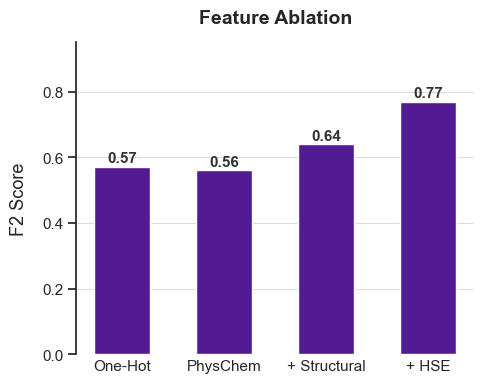

In [24]:

# ── config ────────────────────────────────────────────────────────────────────
COLOR = "#531B93"
# ─────────────────────────────────────────────────────────────────────────────

features = ["One-Hot", "PhysChem", "+ Structural", "+ HSE"]
values   = [0.57, 0.56, 0.64, 0.77]

sns.set_theme(style="ticks", font="sans-serif")
fig, ax = plt.subplots(figsize=(5, 4))

bars = ax.bar(features, values, color=COLOR, width=0.55, zorder=2)

for bar in bars:
    v = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.005,
            f"{v:.2f}", ha="center", va="bottom", fontsize=11, fontweight="bold", color="#333333")

ax.set_ylabel("F2 Score", fontsize=13, labelpad=10)
ax.set_title("Feature Ablation", fontsize=14, fontweight="bold", pad=14)
ax.set_ylim(0, 0.95)
ax.tick_params(axis="both", labelsize=11)
ax.tick_params(axis="x", length=0)
ax.grid(axis="y", color="#dddddd", linewidth=0.8, zorder=0)
sns.despine(left=False, bottom=True)

plt.tight_layout()
plt.savefig("figs/ablation.svg", format="svg", bbox_inches="tight")
plt.show()
